# Scorecard 📋
### Does Piotroski's 9-point health check pick large-cap winners?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![F-score sorts large-cap winners?: Not supported](https://img.shields.io/badge/F--score_sorts_large--cap_winners%3F-Not_supported-8b949e?style=flat-square)

Joseph Piotroski's F-score is a finance classic: nine simple checks of a company's books (is it profitable? generating cash? cutting debt?) summed into a 0–9 health score. High scores are supposed to beat low scores. We built it on real SEC filings for the S&P 500 — and the *low*-score firms (+22.2%/yr) actually *beat* the high-score ones (+18.5%).

> 📓 **Plain-language layer.** The long-short, the inverted sign, and the small-cap-value explanation are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every number is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (scorecard/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from scorecard import data, strategy as st
sig, fwd = data.fetch_panel()                  # cache-first (shared EDGAR pull)
h = st.quantile_hedge(sig, fwd, q=0.3, long_high=True)   # long high-F, short low-F


## The answer first 🎯

| The question | The data (~237 S&P names, ~2009–2025) |
|---|---|
| "Do high-F firms beat low-F firms?" | No — they **lag** by ~3.7%/yr here. |
| "Is the famous screen tradable on large caps?" | No: hedge **−3.7%/yr, Sharpe −0.39**. |
| "So where does it work?" | In small-cap *value* — the universe Piotroski built it for. |

## 1 · The claim

Piotroski (2000): score each firm 0–9 on nine fundamental signals — profitability (ROA>0, cash flow>0, improving ROA, cash>earnings), leverage/liquidity (less debt, better current ratio, no dilution) and efficiency (rising margin and asset turnover). Buy the 8–9s, avoid the 0–2s. The folk version: *good books, good stock.*

## 2 · So what?

If the score sorts winners on the names you can trade in size, it's a free, transparent quality screen straight from 10-K filings — no black box. The question is whether an effect discovered in small, neglected value stocks survives on the blue-chip S&P 500.

## 3 · How would we even know?

Pull the nine concepts from EDGAR for the S&P 500, compute each firm's F-score every year, sort, go long the top-tercile (8–9-ish) and short the bottom-tercile (0–2-ish), and measure next year's hedge over the XBRL era.

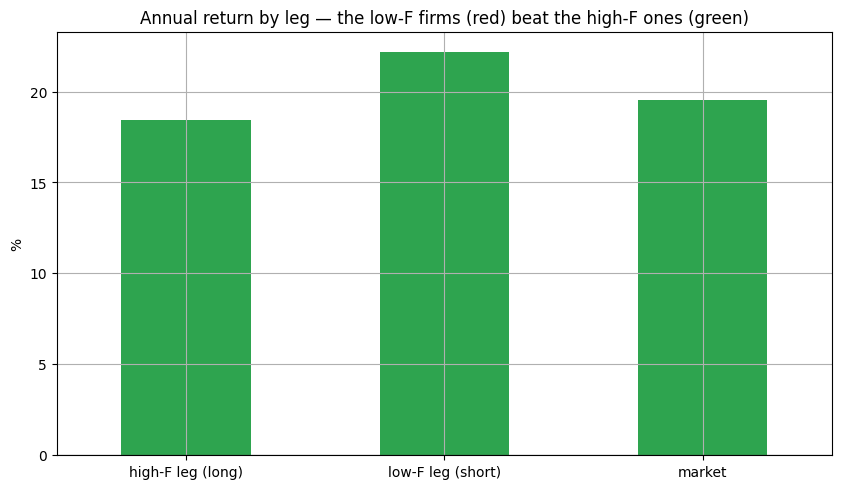

In [2]:
legs = pd.DataFrame({'high-F leg (long)': st.summary(h['high'])['mean'],
                     'low-F leg (short)': st.summary(h['low'])['mean'],
                     'market': st.summary(st.market_annual(fwd).reindex(h.index))['mean']},
                    index=['annual return'])
ax=(legs.T*100).plot.bar(rot=0,legend=False,color=['#2ea44f','#c0392b','#8b949e'],
    title='Annual return by leg — the low-F firms (red) beat the high-F ones (green)')
ax.set_ylabel('%'); ax.axhline(0,color='k',lw=.8); plt.show()

## 4 · The teardown — the sign is backwards

The hedge that's *supposed* to pay (long healthy, short weak) lost money, and lost it in two-thirds of years.

hedge (long high-F, short low-F): -3.73%/yr  Sharpe -0.39  (t~-1.7)  hit 33%


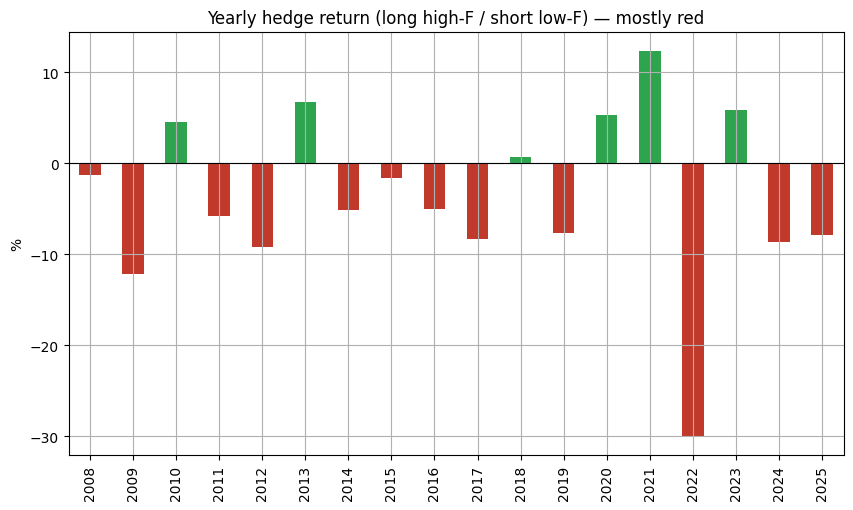

In [3]:
s=st.summary(h['hedge'])
print(f"hedge (long high-F, short low-F): {s['mean']:+.2%}/yr  Sharpe {s['sharpe']:.2f}  (t~{s['tstat']:.1f})  hit {s['hit_rate']:.0%}")
(h['hedge']*100).plot.bar(color=['#2ea44f' if v>0 else '#c0392b' for v in h['hedge']],
    title='Yearly hedge return (long high-F / short low-F) — mostly red')
plt.ylabel('%'); plt.axhline(0,color='k',lw=.8); plt.show()

**Read it plainly.** Piotroski built the F-score to separate winners *within small, neglected value stocks*. On heavily-analyzed large caps a strong balance sheet is already in the price, and the beaten-down low-F names (cyclicals, troughing growth) often snap back — so the short leg wins and the hedge inverts.

## 5 · The verdict

**Signal: Weak** — it inverts (−3.7%/yr, t −1.7). **Tradability: Mirage** — wrong sign on the S&P 500. **F-score sorts large-cap winners?: Not supported.** It's a small-cap value effect.

## 6 · Could you actually trade it?

Not on this universe. Piotroski's edge lives in high book-to-market small caps — illiquid, under-covered, where a clean balance sheet is a genuine surprise. On the S&P 500 that surprise is gone. A real, celebrated factor, measured in the wrong place.

## 7 · Going further 🚪

The quality sibling of [51 Blue-Chip](../../51-blue-chip/) and a cousin of [52 Smoke-Screen](../../52-smoke-screen/) (accruals, which *does* replicate) and [64 Share-Shuffle](../../64-share-shuffle/) (net issuance, also inverted). Forks: a small-cap value universe, the F-score *within* high-B/M, score changes vs levels.